No local CSV with pit-stop target column found. Attempting Kaggle download...
Path to dataset files: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction
Loaded dataset from: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv
Dataset name: f1_strategy_dataset_v4
Raw dataset shape: (101371, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']
Features after encoding: 73
=== Training all models ===
  Logistic Regression
  Decision Tree
  k-NN
  Random Forest
  XGBoost

--- Rank Table (1 = best) ---
                     Rank(Accuracy)  Rank(Precision)  Rank(Recall)  Rank(F1-score)  Rank(AUC)
Logistic Regression               5                4             5               5          5
Decision Tree                     4            

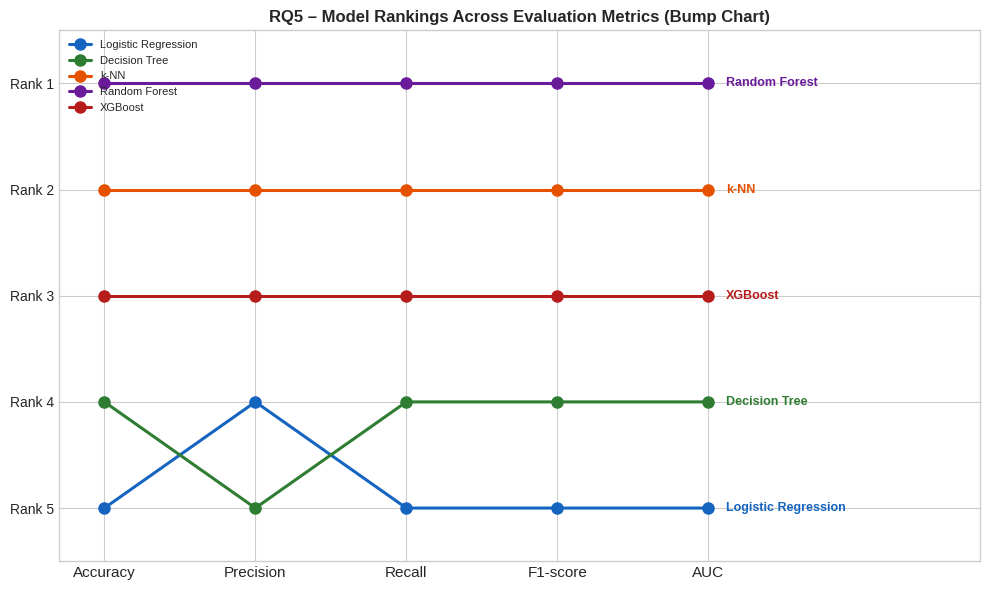

Figure saved → figures/RQ5_bump_chart.png


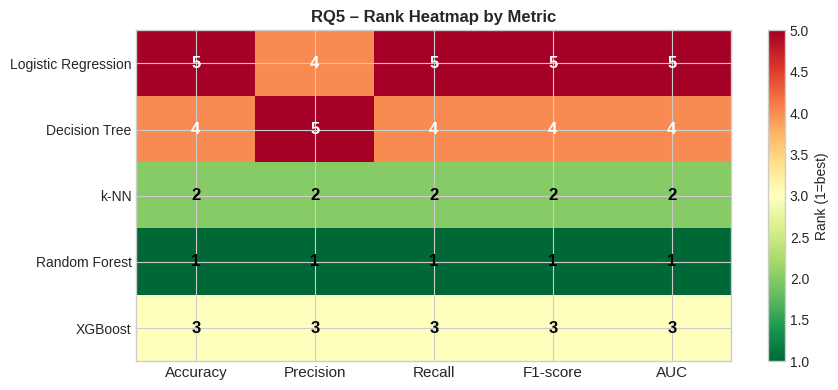

Figure saved → figures/RQ5_rank_heatmap.png


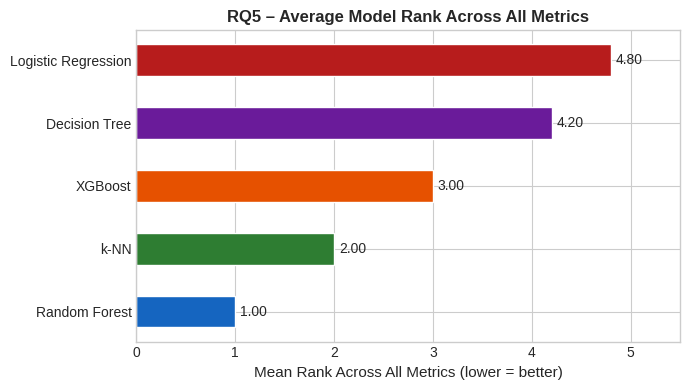

Figure saved → figures/RQ5_mean_rank.png

=== RQ5 Key Observations ===
  Best model by Accuracy    : Random Forest  (0.9726)
  Best model by Precision   : Random Forest  (0.9625)
  Best model by Recall      : Random Forest  (0.9271)
  Best model by F1-score    : Random Forest  (0.9445)
  Best model by AUC         : Random Forest  (0.9960)

  Most consistent model (lowest mean rank): Random Forest  (mean rank = 1.00)


In [1]:
"""
RQ5: How does the relative ranking of candidate models change when
     evaluated across different metrics
     (Accuracy, Precision, Recall, F1-score, AUC)?
"""

try:
    import kagglehub
except ImportError:
    kagglehub = None
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#B71C1C", "#006064"]

# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
# Prefer a local CSV file; fall back to Kaggle download only when needed.
local_csvs = sorted(glob.glob("*.csv"))
raw_path = None

csv_file = None
valid_targets = {"pit_stop", "PitStop", "pitstop", "pit stop"}
for candidate in local_csvs:
    try:
        sample = pd.read_csv(candidate, nrows=5)
    except Exception:
        continue
    if valid_targets.intersection(set(sample.columns.str.replace(" ", "").str.lower())):
        csv_file = candidate
        break

if csv_file is not None:
    print(f"Using local dataset file: {csv_file}")
else:
    if kagglehub is None:
        raise RuntimeError(
            "No local dataset CSV found and kagglehub is not installed. "
            "Please place the dataset CSV in this folder or install kagglehub to enable fallback download."
        )
    print("No local CSV with pit-stop target column found. Attempting Kaggle download...")
    try:
        raw_path = kagglehub.dataset_download("aadigupta1601/f1-strategy-dataset-pit-stop-prediction")
        print("Path to dataset files:", raw_path)
    except Exception as exc:
        raise RuntimeError(
            "Dataset download failed. Please place the dataset CSV in this folder or fix Kaggle SSL/authentication. "
            "If you have the CSV locally, name it something like 'f1_strategy.csv' and rerun."
        ) from exc

    if os.path.isfile(raw_path) and raw_path.lower().endswith(".zip"):
        extract_dir = os.path.splitext(raw_path)[0]
        if not os.path.exists(extract_dir):
            with zipfile.ZipFile(raw_path, "r") as archive:
                archive.extractall(extract_dir)
        data_dir = extract_dir
    else:
        data_dir = raw_path

    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in dataset path: {data_dir}")

    csv_file = sorted(csv_files)[0]

if csv_file is None:
    raise FileNotFoundError("No dataset CSV file could be loaded.")

df = pd.read_csv(csv_file)
dataset_name = os.path.splitext(os.path.basename(csv_file))[0]
print(f"Loaded dataset from: {csv_file}")
print(f"Dataset name: {dataset_name}")
print(f"Raw dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Standardize target column for pit-stop prediction.
found_target = None
for name in df.columns:
    nkey = name.replace(" ", "").replace("_", "").lower()
    if nkey == "pitstop":
        found_target = name
        break

if found_target is None:
    raise ValueError("Target column for pit-stop prediction not found in dataset")

if found_target != "pit_stop":
    df = df.rename(columns={found_target: "pit_stop"})
    found_target = "pit_stop"

# Encode non-numeric target if needed
if df["pit_stop"].dtype == object:
    df["pit_stop"], labels = pd.factorize(df["pit_stop"])
    print("Target encoding:", dict(enumerate(labels)))

# Drop rows with missing labels and keep only useful features
features = [c for c in df.columns if c != "pit_stop"]
X_df = df[features].copy()
X_df = pd.get_dummies(X_df, drop_first=True)

print(f"Features after encoding: {X_df.shape[1]}")

df = pd.concat([X_df, df[["pit_stop"]]], axis=1)

FEATURES = [c for c in df.columns if c != "pit_stop"]
X = df[FEATURES].values
y = df["pit_stop"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 2. TRAIN ALL MODELS ──────────────────────────────────────────────────────
models_cfg = {
    "Logistic Regression": (LogisticRegression(max_iter=300, random_state=42),            True),
    "Decision Tree":       (DecisionTreeClassifier(max_depth=8, random_state=42),          False),
    "k-NN":                (KNeighborsClassifier(n_neighbors=11),                          True),
    "Random Forest":       (RandomForestClassifier(n_estimators=100, random_state=42,
                                                   n_jobs=-1),                             False),
    "XGBoost":             (XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                          eval_metric="logloss", random_state=42,
                                          n_jobs=-1),                                      False),
}

results = {}
print("=== Training all models ===")
for name, (mdl, scale) in models_cfg.items():
    Xtr = X_train_sc if scale else X_train
    Xte = X_test_sc  if scale else X_test
    mdl.fit(Xtr, y_train)
    yp    = mdl.predict(Xte)
    yprob = mdl.predict_proba(Xte)[:, 1]
    results[name] = {
        "Accuracy":  accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp, zero_division=0),
        "Recall":    recall_score(y_test, yp),
        "F1-score":  f1_score(y_test, yp),
        "AUC":       roc_auc_score(y_test, yprob),
    }
    print(f"  {name}")

RANK_METRICS = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]
model_list   = list(results.keys())

# ── 3. COMPUTE RANK TABLE ────────────────────────────────────────────────────
rank_df = pd.DataFrame(index=model_list)
for m in RANK_METRICS:
    sorted_vals = sorted([results[nm][m] for nm in model_list], reverse=True)
    # Rank 1 = best; ties get the same rank
    rank_df[f"Rank({m})"] = [sorted_vals.index(results[nm][m]) + 1 for nm in model_list]

print("\n--- Rank Table (1 = best) ---")
print(rank_df.to_string())

# Mean rank across all metrics
rank_df["Mean Rank"] = rank_df.mean(axis=1).round(2)
print("\n--- Mean Rank (lower = better) ---")
print(rank_df[["Mean Rank"]].sort_values("Mean Rank").to_string())

# ── 4. FIGURE A: Bump / Slope Chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(RANK_METRICS))
for i, mdl in enumerate(model_list):
    ranks = [rank_df.loc[mdl, f"Rank({m})"] for m in RANK_METRICS]
    ax.plot(x_pos, ranks, "o-", color=COLORS[i % 6], label=mdl, lw=2.2, ms=8)
    ax.text(x_pos[-1] + 0.12, ranks[-1], mdl, va="center",
            fontsize=9, color=COLORS[i % 6], fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(RANK_METRICS, fontsize=11)
ax.set_yticks(range(1, len(model_list) + 1))
ax.set_yticklabels([f"Rank {r}" for r in range(1, len(model_list) + 1)], fontsize=10)
ax.set_ylim(len(model_list) + 0.5, 0.5)   # rank 1 at top
ax.set_xlim(-0.3, len(RANK_METRICS) + 0.8)
ax.set_title("RQ5 – Model Rankings Across Evaluation Metrics (Bump Chart)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("figures/RQ5_bump_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ5_bump_chart.png")

# ── 5. FIGURE B: Rank heatmap ────────────────────────────────────────────────
rank_heat = rank_df[[f"Rank({m})" for m in RANK_METRICS]].astype(int)
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(rank_heat.values, aspect="auto", cmap="RdYlGn_r",
               vmin=1, vmax=len(model_list))
plt.colorbar(im, ax=ax, label="Rank (1=best)")
ax.set_xticks(range(len(RANK_METRICS)))
ax.set_xticklabels(RANK_METRICS, fontsize=11)
ax.set_yticks(range(len(model_list)))
ax.set_yticklabels(model_list, fontsize=10)
for i in range(len(model_list)):
    for j in range(len(RANK_METRICS)):
        ax.text(j, i, str(rank_heat.iloc[i, j]),
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="white" if rank_heat.iloc[i, j] > 3 else "black")
ax.set_title("RQ5 – Rank Heatmap by Metric", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ5_rank_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ5_rank_heatmap.png")

# ── 6. FIGURE C: Mean rank bar ───────────────────────────────────────────────
mean_sorted = rank_df["Mean Rank"].sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(mean_sorted.index, mean_sorted.values,
               color=[COLORS[i % 6] for i in range(len(mean_sorted))],
               edgecolor="white", height=0.5)
for bar, v in zip(bars, mean_sorted.values):
    ax.text(v + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}", va="center", fontsize=10)
ax.set_xlabel("Mean Rank Across All Metrics (lower = better)", fontsize=11)
ax.set_xlim(0, len(model_list) + 0.5)
ax.set_title("RQ5 – Average Model Rank Across All Metrics",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ5_mean_rank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ5_mean_rank.png")

# ── 7. INSIGHT SUMMARY ───────────────────────────────────────────────────────
print("\n=== RQ5 Key Observations ===")
for m in RANK_METRICS:
    best = min(model_list, key=lambda nm: rank_df.loc[nm, f"Rank({m})"])
    print(f"  Best model by {m:12s}: {best}  "
          f"({results[best][m]:.4f})")
overall_best = mean_sorted.index[0]
print(f"\n  Most consistent model (lowest mean rank): {overall_best}  "
      f"(mean rank = {mean_sorted.iloc[0]:.2f})")